In [ ]:
!pip install efficientnet_pytorch timm pretrainedmodels


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=1bf68067de7d77a980b4a45e564332614fb49f2ba7130fc3e91ebbb81020f38f
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60945 sha256=cda1b743dedf8212547e9cbb914c5ffac544eb567094b9473bd1342d169883e9
  Stored in directory: /root/.cache/pip/wheels/4c/01/56/40a48f75dbdfe167a0cb70d3b48913369a00ec5c4e9fed5f2b
Successfully built efficientnet_pytorch pretrainedmodels


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2
import os
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report


In [ ]:
class MRIClassifierDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = []
        self.labels = []
        self.transform = transform

        self.classes = ["1", "2", "3", "no_tumor"]
        self.class_to_idx = {cls:i for i, cls in enumerate(self.classes)}

        for cls in self.classes:
            folder = os.path.join(root_dir, cls)
            for img_name in os.listdir(folder):
                self.paths.append(os.path.join(folder, img_name))
                self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx], cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (224,224))

        img = np.stack([img, img, img], axis=2)  # grayscale → 3ch

        if self.transform:
            img = self.transform(img)

        label = self.labels[idx]
        return img, label


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

DATA_ROOT = "/content/drive/MyDrive/RETEST__brainTUMOR/data/enhanced/unet"

train_ds = MRIClassifierDataset(DATA_ROOT + "/train", transform)
val_ds   = MRIClassifierDataset(DATA_ROOT + "/val", transform)
test_ds  = MRIClassifierDataset(DATA_ROOT + "/test", transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

print(len(train_ds), len(val_ds), len(test_ds))


2213 635 496


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    model.train()
    return correct / total

def test_model(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(predicted.cpu().numpy())

    print("\n🔍 Test Classification Report:\n")
    print(classification_report(y_true, y_pred))


In [ ]:
from torchvision.models import vgg16

model = vgg16(pretrained=True)
model.classifier[6] = nn.Linear(4096, 4)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 196MB/s]


In [ ]:
# ==========================
#  VGG16 TRAINING CODE
# ==========================

vgg_train_acc = []
vgg_val_acc = []
vgg_train_loss = []

best_acc = 0
patience = 5
no_improve = 0

def train_vgg():
    global best_acc, no_improve

    for epoch in range(15):
        model.train()
        correct = 0
        total = 0
        running_loss = 0

        for imgs, labels in tqdm(train_loader):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, pred = torch.max(out, 1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_loss = running_loss / total
        val_acc = evaluate(model, val_loader)

        vgg_train_acc.append(train_acc)
        vgg_val_acc.append(val_acc)
        vgg_train_loss.append(train_loss)

        print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            no_improve = 0
            torch.save(model.state_dict(), "vgg16_best.pth")
            print("✓ Saved BEST VGG16 Model")
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"⛔ Early Stopping at Epoch {epoch+1}")
            break

    print("\nVGG16 Training Done!")


In [ ]:
train_vgg()
model.load_state_dict(torch.load("vgg16_best.pth"))
test_model(model, test_loader)


100%|██████████| 139/139 [10:30<00:00,  4.54s/it]


Epoch 1 | Train Acc: 0.8052 | Val Acc: 0.8126
✓ Saved BEST VGG16 Model


100%|██████████| 139/139 [00:51<00:00,  2.69it/s]


Epoch 2 | Train Acc: 0.9164 | Val Acc: 0.8661
✓ Saved BEST VGG16 Model


100%|██████████| 139/139 [00:51<00:00,  2.69it/s]


...

Epoch 13 | Train Acc: 0.9995 | Val Acc: 0.9685
✓ Saved BEST VGG16 Model


100%|██████████| 139/139 [00:51<00:00,  2.72it/s]


Epoch 14 | Train Acc: 1.0000 | Val Acc: 0.9685


100%|██████████| 139/139 [00:50<00:00,  2.75it/s]


Epoch 15 | Train Acc: 1.0000 | Val Acc: 0.9685

VGG16 Training Done!

🔍 Test Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.85      0.88        75
           1       0.93      0.99      0.96       140
           2       0.78      0.97      0.86        94
           3       1.00      0.85      0.92       187

    accuracy                           0.91       496
   macro avg       0.90      0.91      0.90       496
weighted avg       0.92      0.91      0.91       496



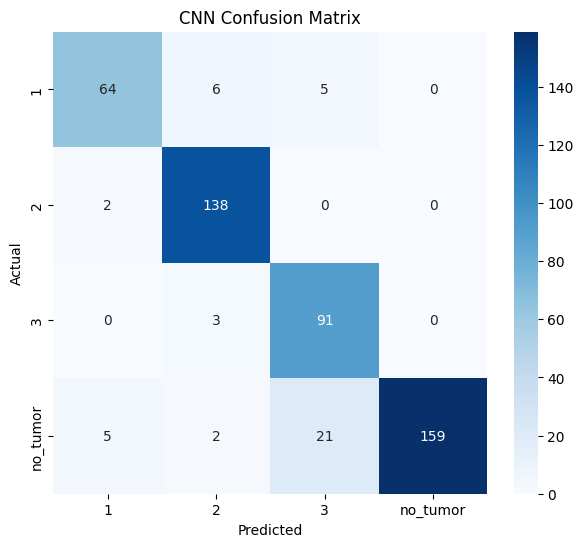

In [ ]:
#------------------Generate Confusion Matrix-------
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Ensure best model is loaded
model.load_state_dict(torch.load("vgg16_best.pth"))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["1","2","3","no_tumor"],
            yticklabels=["1","2","3","no_tumor"])
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
#----Compute Specificity for Each Class
#  Specificity = TN / (TN + FP)

import numpy as np

cm = confusion_matrix(y_true, y_pred)
specificity = {}

for i, cls in enumerate(["1","2","3","no_tumor"]):
    TN = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
    FP = cm[:,i].sum() - cm[i,i]
    specificity[cls] = TN / (TN + FP)

print("Specificity per class:")
for cls, spec in specificity.items():
    print(cls, ":", round(spec, 4))


Specificity per class:
1 : 0.9834
2 : 0.9691
3 : 0.9353
no_tumor : 1.0


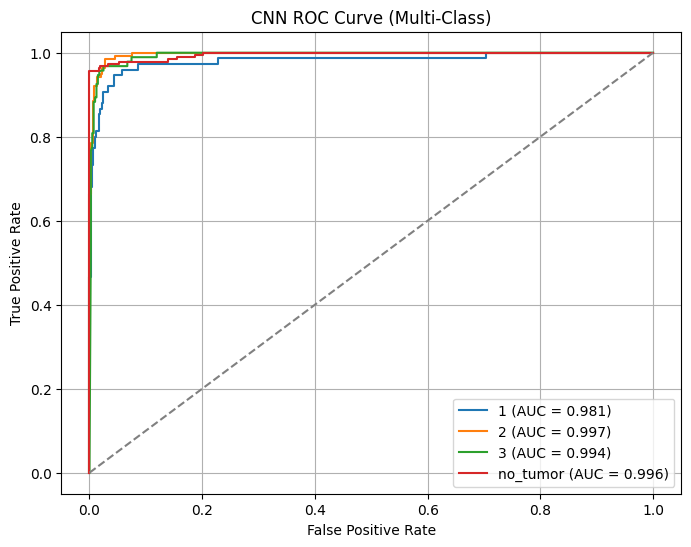

In [ ]:
#-----------ROC Curve for Multi-Class

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

model.eval()

y_true = []
y_score = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()

        y_true.extend(labels.numpy())
        y_score.extend(probs)

y_true_onehot = label_binarize(y_true, classes=[0,1,2,3])
y_score = np.array(y_score)

plt.figure(figsize=(8,6))

for i, cls in enumerate(["1","2","3","no_tumor"]):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],"--", color="gray")
plt.title("CNN ROC Curve (Multi-Class)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()


In [ ]:
  #------------------Print Final Metrics Table----

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("\n=== CNN FINAL METRICS ===")
print("Accuracy:      ", round(acc,4))
print("Precision:     ", round(prec,4))
print("Recall:        ", round(rec,4))
print("F1 Score:      ", round(f1,4))

print("\nSpecificity per class:", specificity)



=== CNN FINAL METRICS ===
Accuracy:       0.9113
Precision:      0.9221
Recall:         0.9113
F1 Score:       0.9121

Specificity per class: {'1': np.float64(0.9833729216152018), '2': np.float64(0.9691011235955056), '3': np.float64(0.9353233830845771), 'no_tumor': np.float64(1.0)}
